This is an implementation of logistic regression for predicting heart disease.

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [ ]:
import pandas as pd

test_df = pd.read_csv('/content/test.csv')
display(test_df.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/train.csv')
display(train_df.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [ ]:
# Convert 'Heart Disease' column to numerical values for correlation calculation
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})


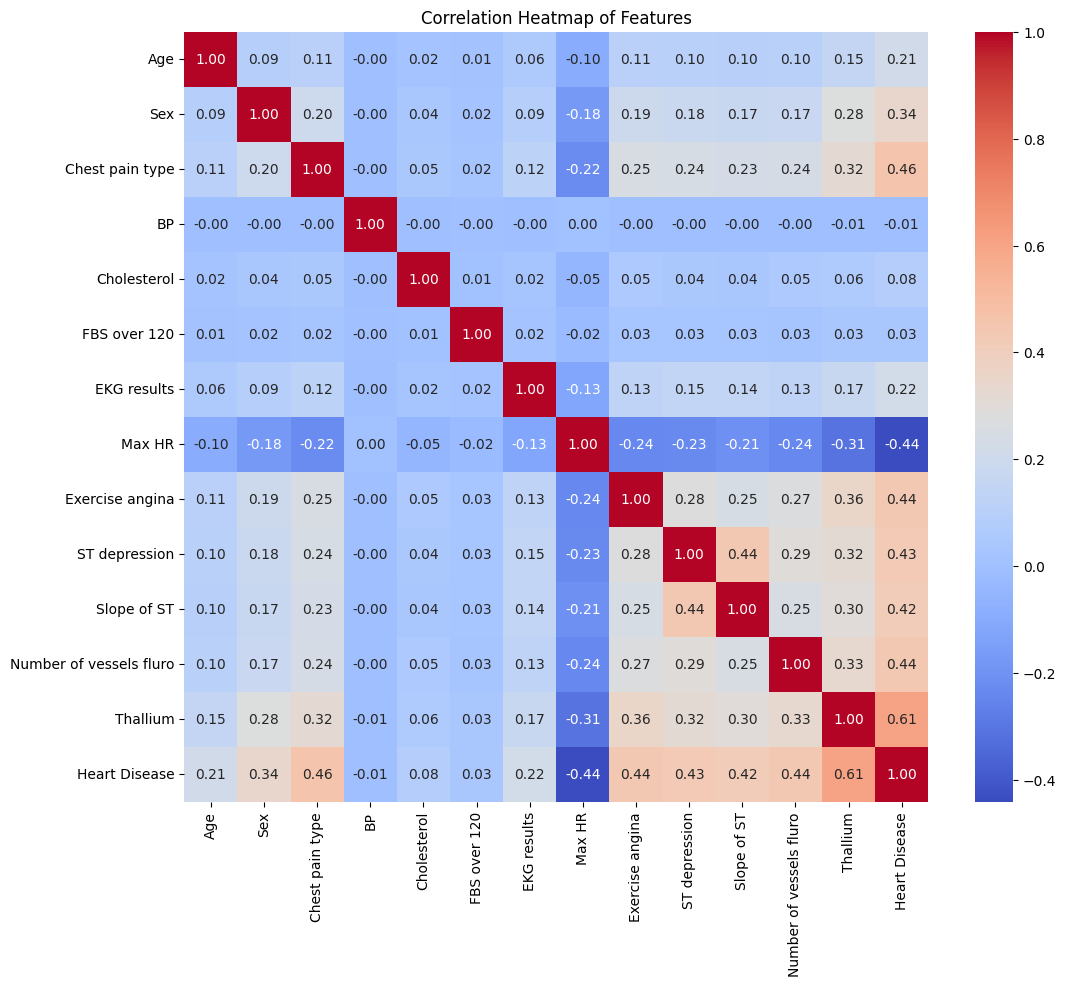

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical features
# Exclude 'id' column for correlation calculation, keep 'Heart Disease'
correlation_matrix = train_df.drop(['id'], axis=1).corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

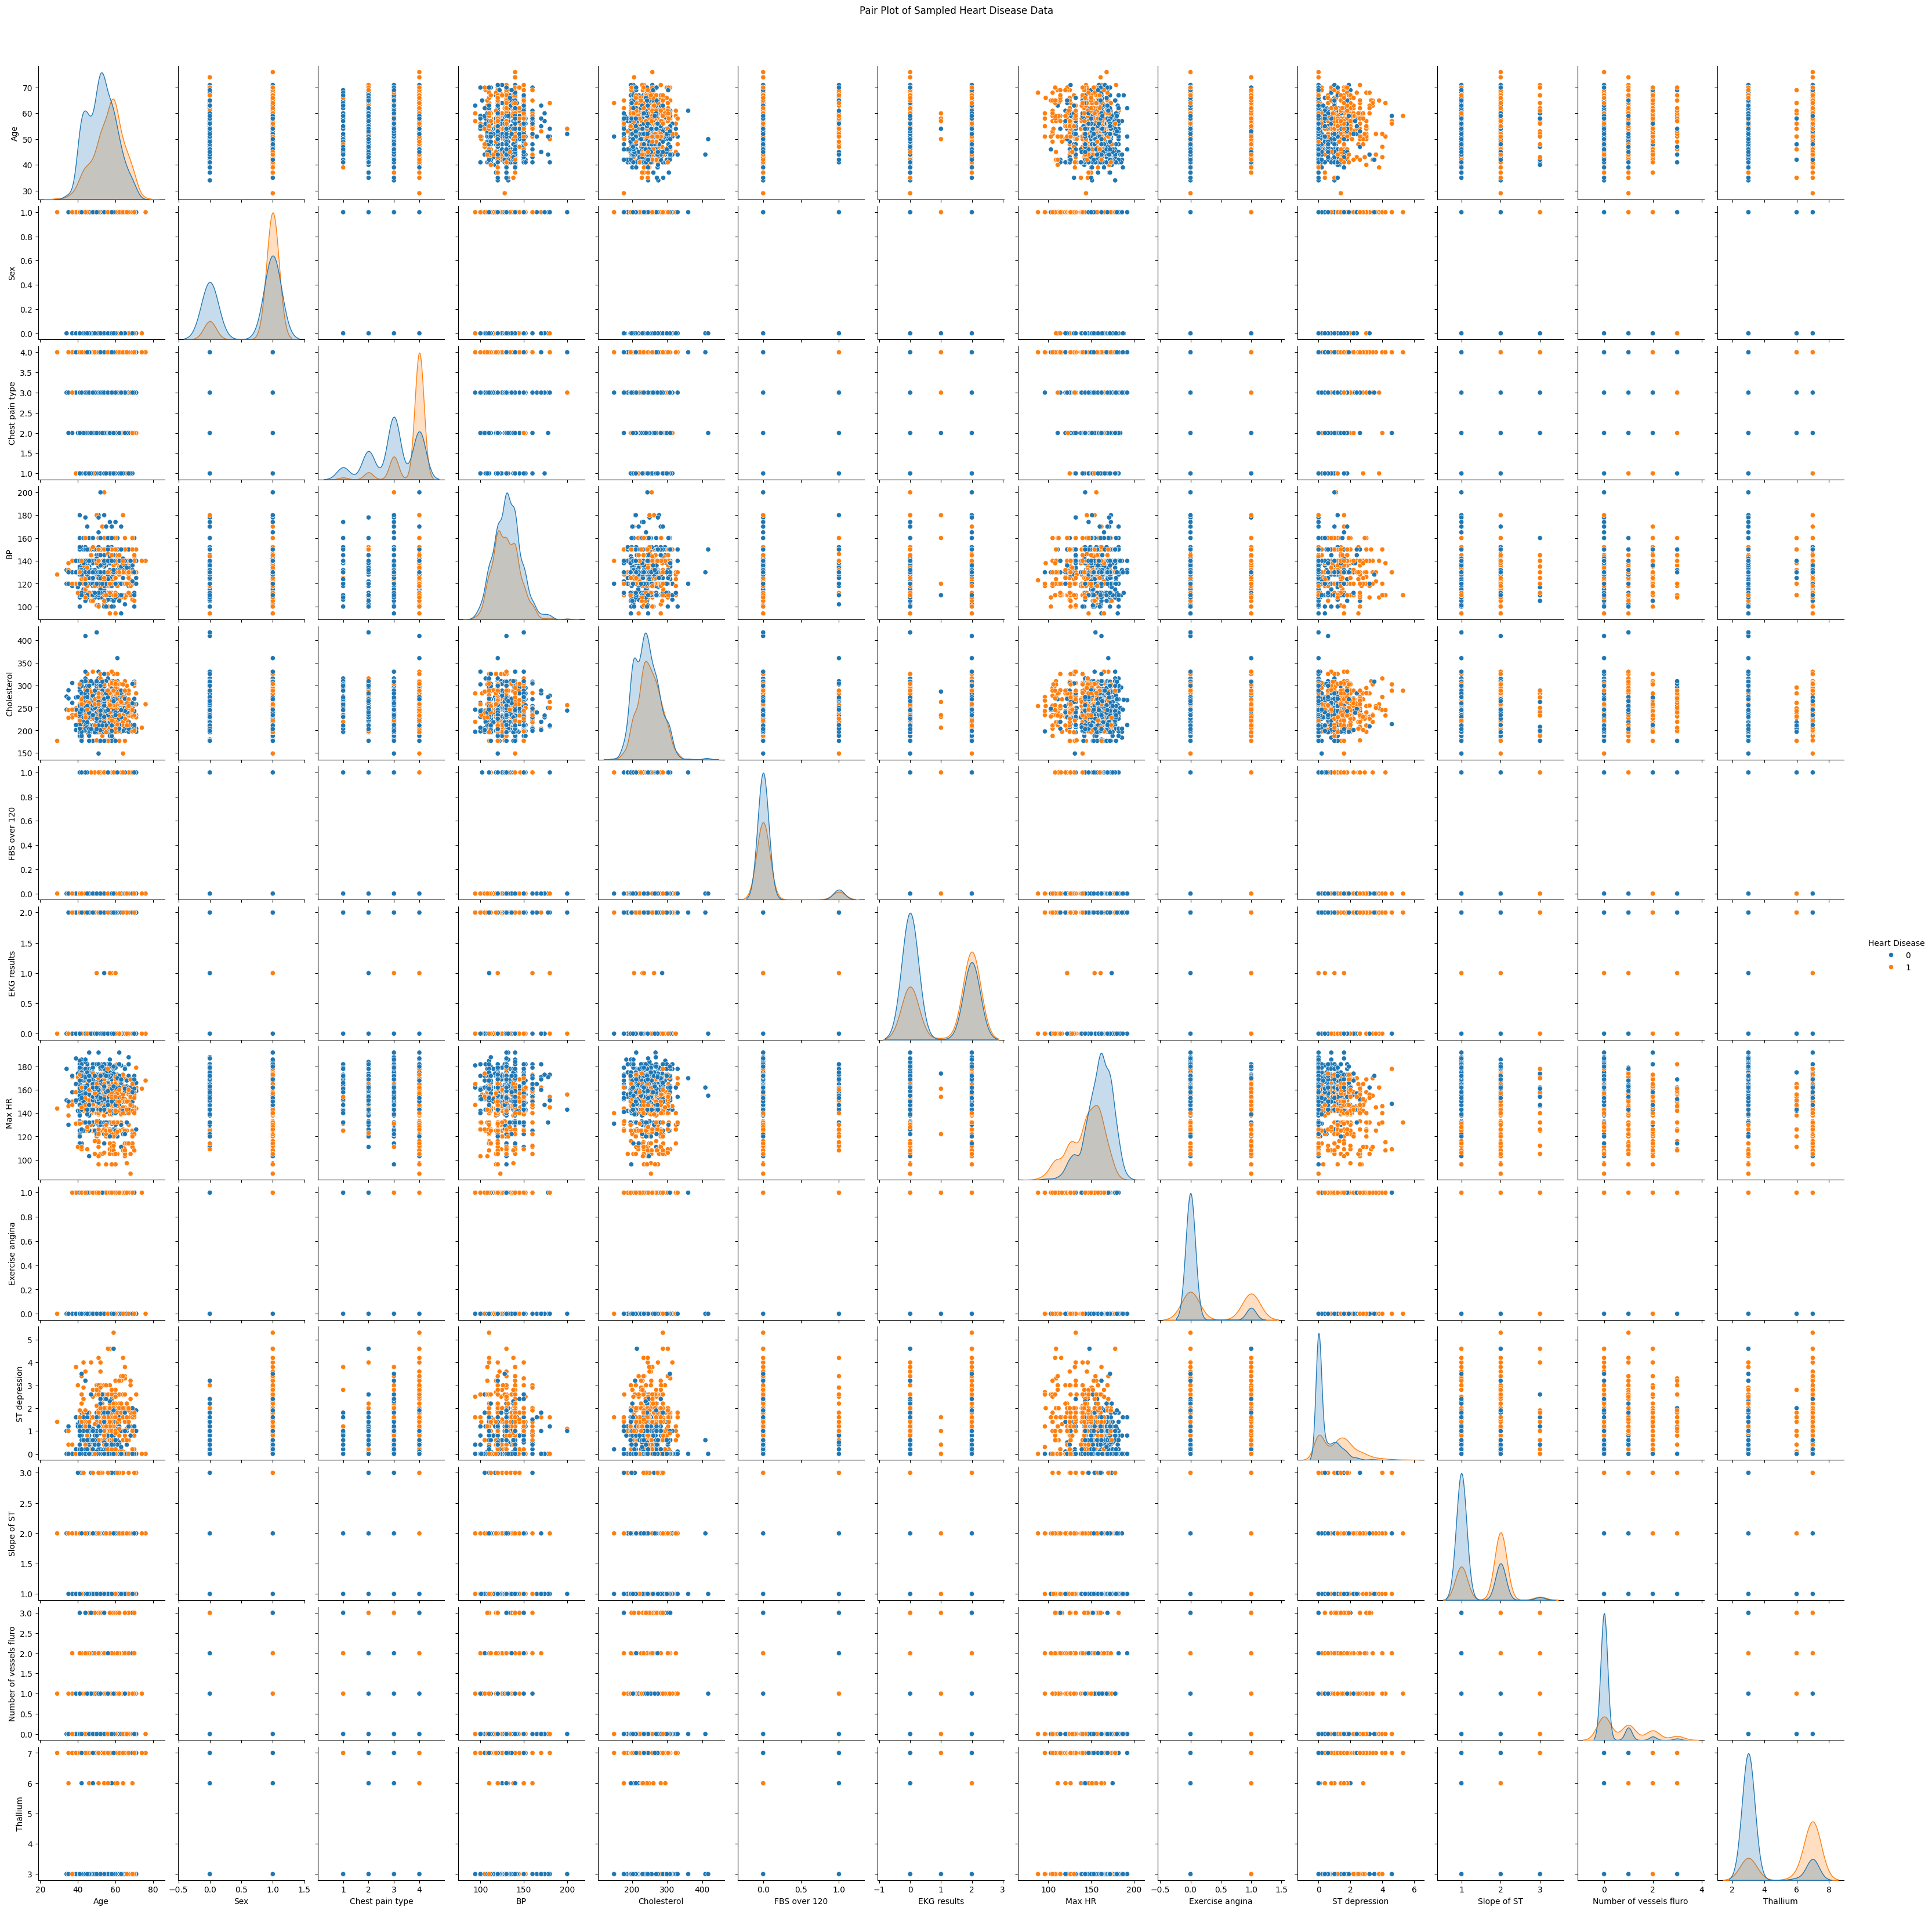

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Re-load train_df and convert 'Heart Disease' if kernel state was lost
train_df = pd.read_csv('/content/train.csv')
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Sample a smaller portion of the data for pair plot due to large dataset size
sampled_df = train_df.sample(n=1000, random_state=42)

# Create a pair plot
sns.pairplot(sampled_df.drop('id', axis=1), hue='Heart Disease', diag_kind='kde')
plt.suptitle('Pair Plot of Sampled Heart Disease Data', y=1.02)
plt.show()

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error # Added import for MSE

# Re-load train_df for a fresh start in this cell
train_df = pd.read_csv('/content/train.csv')

# --- Diagnostic Step ---
print("Value counts before mapping:")
print(train_df['Heart Disease'].value_counts(dropna=False))
# --- End Diagnostic Step ---

# Convert 'Heart Disease' column to numerical values
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Define features (X) and target (y)
X_train = train_df.drop(['id', 'Heart Disease'], axis=1)
y_train = train_df['Heart Disease']

# Drop rows where y_train is NaN (missing target values)
# This ensures both X_train and y_train are aligned after dropping
valid_indices = y_train.dropna().index
X_train = X_train.loc[valid_indices]
y_train = y_train.loc[valid_indices]

# Check if X_train or y_train are empty after cleaning
if X_train.empty or y_train.empty:
    print("Warning: X_train or y_train is empty after dropping NaN values.")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
else:
    # Initialize and fit the Logistic Regression model
    model = LogisticRegression(max_iter=1500) # Increased max_iter for convergence
    model.fit(X_train, y_train)

    print("Logistic Regression model fitted successfully!")

    # Predict probabilities for the training set
    train_probabilities = model.predict_proba(X_train)[:, 1]

    # Calculate Mean Squared Error (MSE) between actual y_train and predicted probabilities
    mse_train = mean_squared_error(y_train, train_probabilities)

    print(f"Mean Squared Error on the training set: {mse_train:.4f}")

Value counts before mapping:
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64
Logistic Regression model fitted successfully!
Mean Squared Error on the training set: 0.0854


In [ ]:
# Prepare the test data (X_test) by dropping the 'id' column
X_test = test_df.drop('id', axis=1)

# Predict probabilities for the test set
# The output will be an array where each row contains [probability_absence, probability_presence]
probabilities = model.predict_proba(X_test)

# Get the probability of 'Presence' (Heart Disease)
# Assuming 'Presence' is the second class (index 1) in the model's classes_
# You can verify model.classes_ to confirm the order
heart_disease_probabilities = probabilities[:, 1]

# Create a DataFrame to store IDs and their predicted probabilities
submission_df = pd.DataFrame({'id': test_df['id'], 'Heart Disease Probability': heart_disease_probabilities})

# Round the 'Heart Disease Probability' to the nearest tenth
submission_df['Heart Disease Probability'] = submission_df['Heart Disease Probability'].round(1)

# Display the first few predictions
display(submission_df.head(25))

,id,Heart Disease Probability
0,630000,1.0
1,630001,0.0
2,630002,1.0
3,630003,0.0
4,630004,0.1
5,630005,1.0
6,630006,0.0
7,630007,0.6
8,630008,1.0
9,630009,0.0


In [ ]:
# Save the submission_df to a CSV file
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")

Submission file 'submission.csv' created successfully!


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error

# Re-load train_df and convert 'Heart Disease' if kernel state was lost
train_df = pd.read_csv('/content/train.csv')
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Define features (X) and target (y) and re-fit model if kernel state was lost
X_train = train_df.drop(['id', 'Heart Disease'], axis=1)
y_train = train_df['Heart Disease']
model = LogisticRegression(max_iter=1500) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Predict probabilities for the training set
train_probabilities = model.predict_proba(X_train)[:, 1]

# Calculate Mean Squared Error (MSE) between actual y_train and predicted probabilities
mse_train = mean_squared_error(y_train, train_probabilities)

print(f"Mean Squared Error on the training set: {mse_train:.4f}")

Mean Squared Error on the training set: 0.0854
